# FEATURE-BASED SET OF EXPERIMENTS: BINARY LABELS (LV-RV)
**Hypothesis**: This set of experiments are done under the hypothesis that feeding the models with more precise and important data, the performance will increase in comparison to feeding the same models with the raw data.

**Content of the file**: This file includes all the experiments done for binary classification of the site-of-origin in idiopathic ventricular arrythmias. First a dataset assessment to see which combination of all the available ones gives a better performance on the Teknon dataset. Followed by the choice of a best model and its refinement. Then a comparison to the performance on training with the Teknon dataset on its own including demographic data.
The test split follows a hold-out strategy with 20% of the teknon samples. All the cross-validation evaluations are done only on Teknon training samples.



### Paths and Constants

Imports

In [1]:
# If you are executing on google colab, mount it
'''from google.colab import drive
drive.mount('/content/drive')'''

"from google.colab import drive\ndrive.mount('/content/drive')"

In [2]:
import os, pickle, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import copy
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch.nn.functional as F
from torch.utils.data import Dataset
from scipy import signal
from scipy.io import loadmat
from scipy.stats import kurtosis, skew
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (f1_score, roc_auc_score, accuracy_score,
                              confusion_matrix, ConfusionMatrixDisplay)
import xgboost as xgb
import shap

print("Imports OK")

Imports OK


In [3]:
# Choose the base path
#base_path = "/content/drive/Shareddrives/CompBioMed/seminars"
base_path = ""

PATH_ALIGNED     = os.path.join(base_path, 'outputs', 'aligned_qrs.pkl')
PATH_IDENTIFIERS = os.path.join(base_path, 'outputs', 'qrs_identifiers.pkl')
PATH_DATA        = os.path.join(base_path, 'data',    'binary_full_dataset.parquet')
PATH_CARTO       = os.path.join(base_path, 'data',    'QRS_CARTO2.mat')
PATH_CHINA       = os.path.join(base_path, 'data',    'QRS_Database2.mat')
PATH_SIMS        = os.path.join(base_path, 'data',    'QRS_Sims2.mat')

PATH_TABULAR_PARQUET = os.path.join(base_path, 'data', 'tabular_dataset.parquet')

SAMPLE_SIZE  = 277
RANDOM_STATE = 42
N_FOLDS      = 5
LEADS        = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']

### Utilities

Loading different datasets functions

In [4]:
def load_teknon():

    print('\n-- Loading Teknon ------------------------------------------')
    with open(PATH_ALIGNED, 'rb') as f:
        aligned_ecgs = pickle.load(f)
    X_all = np.array(aligned_ecgs, dtype=np.float32)
    X_all = np.transpose(X_all, (0, 2, 1))   # → (N, 12, T)

    with open(PATH_IDENTIFIERS, 'rb') as f:
        df_id = pickle.load(f)

    df_full  = pd.read_parquet(PATH_DATA)
    Y_tab    = df_full['Chamber_Type']
    indices  = df_id.index.intersection(Y_tab.index)

    y_raw = Y_tab.loc[indices].values
    pos   = [df_id.index.get_loc(i) for i in indices]
    X_tek = X_all[pos]

    mapping = {'LV': 0, 'RV': 1}
    y_tek   = np.array([mapping[v] if v in mapping else int(v) for v in y_raw],
                       dtype=np.int64)

    global_teknon_transition = df_full.loc[indices, 'PVC_transition'].values

    print(f'  Shape: {X_tek.shape}  |  LV={( y_tek==0).sum()}  RV={(y_tek==1).sum()}')
    return X_tek, y_tek, global_teknon_transition

In [5]:
def _build_binary_target(dSim, data_key):
    mapping  = {'LV': 0, 'RV': 1}
    key_name = ('LeftRight' if 'LeftRight' in dSim[data_key].dtype.names
                else 'LeftRigth')
    raw_labels = dSim[data_key][key_name]
    y = np.zeros(len(raw_labels[0]), dtype=np.int64)
    for i, label in enumerate(raw_labels[0]):
        y[i] = mapping[label[0]]
    return y


def _handle_sublocation(dSim, data_key, path, X, y):
    mapping = {
        'LCC': 0, 'RCC': 1, 'COMMISSURE': 2, 'LVOT Subvalvular': 3,
        'LVOT Summit': 4, 'RVOT Septum': 5, 'RFW': 6, 'Undefined': 7
    }
    raw_labels  = dSim[data_key]['Sublocation']
    y_sub, valid_indices = [], []

    for i, label in enumerate(raw_labels[0]):
        try:
            lbl = 'Undefined' if len(label) == 0 else label[0]
            if lbl in ['LCCRCC', 'LCC-RCC']:              lbl = 'COMMISSURE'
            elif lbl in ['Posteroseptal', 'Anteroseptal']: lbl = 'RVOT Septum'
            elif lbl == 'AMC':                             lbl = 'LVOT Subvalvular'
            elif lbl == 'Summit':                          lbl = 'LVOT Summit'
            elif lbl in ['RV', '-', 'RVOTOther']:         lbl = 'Undefined'
            if lbl in mapping:
                y_sub.append(mapping[lbl])
                valid_indices.append(i)
        except Exception:
            continue

    return X[valid_indices], y[valid_indices], np.array(y_sub)


def _load_mat_dataset(path, sample_size, data_key, lead_names, sublocation):
    dSim      = loadmat(path)
    n_patients = dSim[data_key][lead_names[0]].shape[1]
    X = np.zeros((n_patients, len(lead_names), sample_size))

    for iLead, lead in enumerate(lead_names):
        lead_data = dSim[data_key][lead]
        for i in range(n_patients):
            sig = np.asarray(lead_data[0, i]).squeeze()
            if sig.ndim != 1:
                continue
            resampled = signal.resample(sig, sample_size)
            if np.max(np.abs(resampled)) > 0:
                resampled = resampled / np.max(np.abs(resampled))
            X[i, iLead, :] = resampled

    y = _build_binary_target(dSim, data_key)
    y_sub = None
    if sublocation:
        X, y, y_sub = _handle_sublocation(dSim, data_key, path, X, y)
    return X, y, y_sub


def load_dataset(path, sample_size, data_key,
                 lead_names=None, sublocation=False, shuffle=False, random_state=None):
    if lead_names is None:
        lead_names = LEADS
    print(f'\n--- Carregant: {path} ---')
    X, y, y_sub = _load_mat_dataset(path, sample_size, data_key, lead_names, sublocation)
    if shuffle:
        rng = np.random.default_rng(random_state)
        idx = rng.permutation(len(X))
        X, y = X[idx], y[idx]
        if y_sub is not None: 
            y_sub = y_sub[idx]
    print(f'  Shape: {X.shape}  |  LV={(y==0).sum()}  RV={(y==1).sum()}')

    if sublocation:
        return X, y, y_sub
    return X, y

Feature handeling functions

In [6]:
def compute_transition(pacient_feats):
    PRECORDIALS = ["V1", "V2", "V3", "V4", "V5", "V6"]
    TRANSITION_MAPPING = {"V1": 1, "V2": 2, "V3": 3, "V4": 4, "V5": 5, "V6": 6}

    ratios = []
    for lead in PRECORDIALS:
        r_amp = pacient_feats[f'{lead}_R_amp']
        s_amp = pacient_feats[f'{lead}_S_amp']
        R = r_amp
        S = abs(s_amp)
        ratio = np.inf if S == 0 else R / S
        ratios.append(ratio)

    ratios = np.array(ratios)
    idx = np.where(ratios >= 1)[0]
    string_trans = PRECORDIALS[idx[0]] if len(idx) > 0 else "V6"
    return TRANSITION_MAPPING[string_trans]

def extract_features_from_dataset(X_ecg, y, source_name, calculate_transition=False, teknon_id_slice=None):
    """
    Passa X_ecg per UniversalECGDataset (→ preprocess_ecg → shape 12×277)
    i extreu 72 features estadístiques per pacient.
    """
    ds = UniversalECGDataset(X_ecg, y)

    records = []
    for idx in range(len(ds)):
        ecg_tensor, _ = ds[idx]          # (12, 277) torch.Tensor
        ecg = ecg_tensor.numpy()         # (12, 277) numpy

        feats = {}
        for i_lead, lead in enumerate(LEADS):
            sig = ecg[i_lead]
            r   = np.max(sig)
            s   = np.min(sig)
            feats[f'{lead}_R_amp']    = r
            feats[f'{lead}_S_amp']    = s
            feats[f'{lead}_RS_ratio'] = r / (abs(s) + 1e-6)
            feats[f'{lead}_RMS']      = np.sqrt(np.mean(sig**2))
            feats[f'{lead}_Kurtosis'] = kurtosis(sig)
            feats[f'{lead}_Skewness'] = skew(sig)

        if calculate_transition:
          feats['PVC_transition'] = compute_transition(feats)
        else:
          feats['PVC_transition'] = teknon_id_slice[idx]
        records.append(feats)

    df = pd.DataFrame(records)
    df['target']  = y
    df['_source'] = source_name
    print(f'  {source_name:<10}  n={len(df):4d}  features={len(df.columns)-2}')
    return df

def extract_features(X_data):
    features_ecg_llista = []
    for i_pacient in range(len(X_data)):
        pacient_feats = {}
        for i_lead, lead_name in enumerate(LEADS):
            senyal = X_data[i_pacient, i_lead, :]

            r_amp = np.max(senyal)
            s_amp = np.min(senyal)
            rs_ratio = r_amp / (abs(s_amp) + 1e-6)
            rms = np.sqrt(np.mean(senyal**2))
            kurt = kurtosis(senyal)
            asimetria = skew(senyal)

            pacient_feats[f'{lead_name}_R_amp'] = r_amp
            pacient_feats[f'{lead_name}_S_amp'] = s_amp
            pacient_feats[f'{lead_name}_RS_ratio'] = rs_ratio
            pacient_feats[f'{lead_name}_RMS'] = rms
            pacient_feats[f'{lead_name}_Kurtosis'] = kurt
            pacient_feats[f'{lead_name}_Skewness'] = asimetria

        pacient_feats['PVC_transition'] = compute_transition(pacient_feats)
        features_ecg_llista.append(pacient_feats)
    return pd.DataFrame(features_ecg_llista)

import numpy as np
import pandas as pd
from scipy.stats import kurtosis, skew

def extract_features_from_array(X_data, y, source_name, calculate_transition=False, teknon_id_slice=None):
    """
    Extract 72 features per pacient directly from QRS NumPy array
    
    X_data: np.ndarray with shape (n_pacients, 12, 277)
    y: array or list with the labels (targets)
    """
    records = []
    
    for idx in range(len(X_data)):
        ecg = X_data[idx] 
        feats = {}
        
        for i_lead, lead in enumerate(LEADS):
            sig = ecg[i_lead]
            
            r   = np.max(sig)
            s   = np.min(sig)
            
            feats[f'{lead}_R_amp']    = r
            feats[f'{lead}_S_amp']    = s
            feats[f'{lead}_RS_ratio'] = r / (abs(s) + 1e-6)
            feats[f'{lead}_RMS']      = np.sqrt(np.mean(sig**2))
            feats[f'{lead}_Kurtosis'] = kurtosis(sig)
            feats[f'{lead}_Skewness'] = skew(sig)
            
        # Flag logic to determine PVC transition only on .mat datasets
        if calculate_transition:
            feats['PVC_transition'] = compute_transition(feats)
        else:
            if teknon_id_slice is not None and idx < len(teknon_id_slice):
                feats['PVC_transition'] = teknon_id_slice[idx]
            else:
                feats['PVC_transition'] = None

        records.append(feats)
        
    # Create DataFrame and add target and source columns
    df = pd.DataFrame(records)
    df['target']  = y
    df['_source'] = source_name
    
    # Substracting 2 columns for 'target' and '_source'
    print(f'  {source_name:<10}  n={len(df):4d}  features={len(df.columns)-2}')
    
    return df

Running experiments funcions

In [7]:
def run_ml_experiment(df_tek_feats, df_extra_feats=None, exp_name='exp'):
    """
    CV 5-fold exclusively on Teknon.
    Extra datasets are ONLY added to the train set of each fold.
   
    Returns: dict with F1 macro per model.
    """
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    models_def = {
        'XGBoost':      xgb.XGBClassifier(
                            n_estimators=150, max_depth=8,
                            random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
        'RandomForest': RandomForestClassifier(
                            n_estimators=200, max_depth=8,
                            random_state=RANDOM_STATE, n_jobs=-1),
        'SVM_RBF':      Pipeline([('imp', SimpleImputer(strategy='median')),
                                  ('sc',  StandardScaler()),
                                  ('clf', SVC(probability=True, random_state=RANDOM_STATE))]),
        'LogReg':       Pipeline([('imp', SimpleImputer(strategy='median')),
                                  ('sc',  StandardScaler()),
                                  ('clf', LogisticRegression(max_iter=1500,
                                                             random_state=RANDOM_STATE))]),
    }

    X_tek = df_tek_feats[FEATURE_COLS].values
    y_tek = df_tek_feats['target'].values.astype(np.int64)

    if df_extra_feats is not None and len(df_extra_feats) > 0:
        X_extra = df_extra_feats[FEATURE_COLS].values
        y_extra = df_extra_feats['target'].values.astype(np.int64)
    else:
        X_extra, y_extra = None, None

    fold_scores = {name: [] for name in models_def}

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_tek, y_tek), 1):
        X_tr_fold = X_tek[tr_idx]
        y_tr_fold = y_tek[tr_idx]
        X_va_fold = X_tek[val_idx]
        y_va_fold = y_tek[val_idx]

        # Afegir extra al train d'aquest fold
        if X_extra is not None:
            X_tr_fold = np.concatenate([X_tr_fold, X_extra], axis=0)
            y_tr_fold = np.concatenate([y_tr_fold, y_extra], axis=0)

        for name, clf in models_def.items():
            import copy
            clf_clone = copy.deepcopy(clf)
            clf_clone.fit(X_tr_fold, y_tr_fold)
            preds = clf_clone.predict(X_va_fold)
            fold_scores[name].append(
                f1_score(y_va_fold, preds, average='macro', zero_division=0))

    results = {name: np.mean(scores) for name, scores in fold_scores.items()}

    print(f'  {exp_name:<35}', end='  ')
    for name, score in results.items():
        print(f'{name}={score:.4f}', end='  ')
    print()
    return results

Plotting functions

In [8]:
# Reusable plotting utility
def plot_results(df, title, ylabel):
    fig, ax = plt.subplots(figsize=(14, 5))
    x = np.arange(len(df))
    
    for i, (m, c) in enumerate(zip(MODEL_NAMES, COLORS)):
        # Calculate the mean and std
        model_mean = df[m].mean()
        model_std = df[m].std()

        #Include the statistics to the label
        label = f'{m} (mean={model_mean:.3f}, std={model_std:.3f})'


        ax.bar(x + i * BAR_WIDTH, df[m], BAR_WIDTH, label=label, color=c, edgecolor='black', linewidth=0.5)
        
    ax.set_xticks(x + BAR_WIDTH * 1.5)
    ax.set_xticklabels(df.index, rotation=25, ha='right', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Chance')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

### 1. Dataset Combination Assessment
Load and prepare all the datasets

In [9]:
# Load the datasets 
X_Sims, y_Sims  = load_dataset(PATH_SIMS,  SAMPLE_SIZE, 'QRS_Sims',  sublocation=False)
X_China,y_China = load_dataset(PATH_CHINA, SAMPLE_SIZE, 'QRS',       sublocation=False)
X_Carto, y_Carto = load_dataset(PATH_CARTO, SAMPLE_SIZE, 'QRS_CARTO', sublocation=False)

X_teknon, y_teknon, tek_pvc_trans = load_teknon()

# Holdout split on Teknon (80% train, 20% test)
split_idx = int(0.8 * len(y_teknon))
X_tek_cv,   y_tek_cv   = X_teknon[:split_idx], y_teknon[:split_idx]   # train/CV
X_tek_test, y_tek_test = X_teknon[split_idx:], y_teknon[split_idx:]   # hold-out

print(f'\n  Hold-out split:')
print(f'    CV set  : {len(X_tek_cv)} pacients  (LV={(y_tek_cv==0).sum()}  RV={(y_tek_cv==1).sum()})')
print(f'    Test set: {len(X_tek_test)} pacients  (LV={(y_tek_test==0).sum()}  RV={(y_tek_test==1).sum()})')

print('\nExtracting features...')

# Divide also the Teknon pvc identifiers
tek_trans_cv   = tek_pvc_trans[:split_idx]
tek_trans_test = tek_pvc_trans[split_idx:]

# Extract features for all datasets
df_tek      = extract_features_from_array(X_tek_cv,   y_tek_cv,   'teknon_cv',   calculate_transition=False, teknon_id_slice=tek_trans_cv)
df_tek_test = extract_features_from_array(X_tek_test, y_tek_test, 'teknon_test', calculate_transition=False, teknon_id_slice=tek_trans_test)

df_sims     = extract_features_from_array(X_Sims,   y_Sims,   'sims',  calculate_transition=True)
df_china    = extract_features_from_array(X_China,  y_China,  'china', calculate_transition=True)
df_carto    = extract_features_from_array(X_Carto,  y_Carto,  'carto', calculate_transition=True)

print('Done.')


--- Carregant: data\QRS_Sims2.mat ---
  Shape: (2496, 12, 277)  |  LV=1456  RV=1040

--- Carregant: data\QRS_Database2.mat ---
  Shape: (333, 12, 277)  |  LV=77  RV=256

--- Carregant: data\QRS_CARTO2.mat ---
  Shape: (43, 12, 277)  |  LV=26  RV=17

-- Loading Teknon ------------------------------------------
  Shape: (177, 12, 277)  |  LV=74  RV=103

  Hold-out split:
    CV set  : 141 pacients  (LV=58  RV=83)
    Test set: 36 pacients  (LV=16  RV=20)

Extracting features...
  teknon_cv   n= 141  features=73
  teknon_test  n=  36  features=73
  sims        n=2496  features=73
  china       n= 333  features=73
  carto       n=  43  features=73
Done.


Execute the experiments for all the dataset combinations in each of the selected Machine learning algorithms

In [10]:
FEATURE_COLS = [c for c in df_tek.columns if c not in ['target', '_source']]
MODEL_NAMES = ['XGBoost', 'RandomForest', 'SVM_RBF', 'LogReg']
COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
BAR_WIDTH = 0.2

# Define identical architecture base models
models_base = {
    'XGBoost': xgb.XGBClassifier(
        n_estimators=150, max_depth=8, random_state=RANDOM_STATE, 
        eval_metric='logloss', verbosity=0
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'SVM_RBF': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('clf', SVC(probability=True, random_state=RANDOM_STATE))
    ]),
    'LogReg': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('clf', LogisticRegression(max_iter=1500, random_state=RANDOM_STATE))
    ]),
}



# Cross-validation experiments
print('ML Experiments — Binary Label classification — CV on Teknon')
resum = []

resum.append({'Experiment': 'exp0: Only Teknon', **run_ml_experiment(df_tek, exp_name='exp0: Only Teknon')})
resum.append({'Experiment': 'exp1: Sims + Teknon', **run_ml_experiment(df_tek, df_sims, exp_name='exp1: Sims + Teknon')})
resum.append({'Experiment': 'exp2: China + Teknon', **run_ml_experiment(df_tek, df_china, exp_name='exp2: China + Teknon')})
resum.append({'Experiment': 'exp3: CARTO + Teknon', **run_ml_experiment(df_tek, df_carto, exp_name='exp3: CARTO + Teknon')})

df_e4 = pd.concat([df_china, df_sims], ignore_index=True)
resum.append({'Experiment': 'exp4: China + Sims + Teknon', **run_ml_experiment(df_tek, df_e4, exp_name='exp4: China + Sims + Teknon')})

df_e5 = pd.concat([df_carto, df_sims], ignore_index=True)
resum.append({'Experiment': 'exp5: CARTO + Sims + Teknon', **run_ml_experiment(df_tek, df_e5, exp_name='exp5: CARTO + Sims + Teknon')})

df_e6 = pd.concat([df_carto, df_china], ignore_index=True)
resum.append({'Experiment': 'exp6: CARTO + China + Teknon', **run_ml_experiment(df_tek, df_e6, exp_name='exp6: CARTO + China + Teknon')})

df_e7 = pd.concat([df_carto, df_china, df_sims], ignore_index=True)
resum.append({'Experiment': 'exp7: Tots (CARTO+China+Sims+Teknon)', **run_ml_experiment(df_tek, df_e7, exp_name='exp7: Tots')})

df_resum = pd.DataFrame(resum).set_index('Experiment')
display(df_resum.round(4))



ML Experiments — Binary Label classification — CV on Teknon
  exp0: Only Teknon                    XGBoost=0.6847  RandomForest=0.6037  SVM_RBF=0.4364  LogReg=0.6908  
  exp1: Sims + Teknon                  XGBoost=0.6791  RandomForest=0.5712  SVM_RBF=0.4117  LogReg=0.4964  
  exp2: China + Teknon                 XGBoost=0.6695  RandomForest=0.6278  SVM_RBF=0.4654  LogReg=0.5895  
  exp3: CARTO + Teknon                 XGBoost=0.6869  RandomForest=0.6418  SVM_RBF=0.5145  LogReg=0.6362  
  exp4: China + Sims + Teknon          XGBoost=0.6356  RandomForest=0.6119  SVM_RBF=0.4000  LogReg=0.4656  
  exp5: CARTO + Sims + Teknon          XGBoost=0.6611  RandomForest=0.5259  SVM_RBF=0.4176  LogReg=0.4917  
  exp6: CARTO + China + Teknon         XGBoost=0.6935  RandomForest=0.6061  SVM_RBF=0.4654  LogReg=0.6467  
  exp7: Tots                           XGBoost=0.6712  RandomForest=0.5677  SVM_RBF=0.4000  LogReg=0.4952  


,XGBoost,RandomForest,SVM_RBF,LogReg
Experiment,,,,
exp0: Only Teknon,0.6847,0.6037,0.4364,0.6908
exp1: Sims + Teknon,0.6791,0.5712,0.4117,0.4964
exp2: China + Teknon,0.6695,0.6278,0.4654,0.5895
exp3: CARTO + Teknon,0.6869,0.6418,0.5145,0.6362
exp4: China + Sims + Teknon,0.6356,0.6119,0.4000,0.4656
exp5: CARTO + Sims + Teknon,0.6611,0.5259,0.4176,0.4917
exp6: CARTO + China + Teknon,0.6935,0.6061,0.4654,0.6467
exp7: Tots (CARTO+China+Sims+Teknon),0.6712,0.5677,0.4000,0.4952


In [11]:
# Hold-out evaluation
print('\nHOLD-OUT TEST EVALUATION')

X_ho = df_tek_test[FEATURE_COLS].values
y_ho = df_tek_test['target'].values.astype(np.int64)

experiments_extra = {
    'exp0: Only Teknon': None,
    'exp1: Sims + Teknon': df_sims,
    'exp2: China + Teknon': df_china,
    'exp3: CARTO + Teknon': df_carto,
    'exp4: China + Sims + Teknon': df_e4,
    'exp5: CARTO + Sims + Teknon': df_e5,
    'exp6: CARTO + China + Teknon': df_e6,
    'exp7: Tots (CARTO+China+Sims+Teknon)': df_e7
}

holdout_results = []
best_score = -1.0
best_cm_data = None
best_model_info = {}

# Train on Full Train/CV configurations and evaluate on Hold-Out
for exp_name, df_extra in experiments_extra.items():
    X_train_full = df_tek[FEATURE_COLS].values
    y_train_full = df_tek['target'].values.astype(np.int64)
    
    if df_extra is not None:
        X_train_full = np.concatenate([X_train_full, df_extra[FEATURE_COLS].values], axis=0)
        y_train_full = np.concatenate([y_train_full, df_extra['target'].values.astype(np.int64)], axis=0)

    row = {'Experiment': exp_name}
    print(f"  Training {exp_name:<40}", end=' -> ')
    
    for name, clf in models_base.items():
        clf_clone = copy.deepcopy(clf)
        clf_clone.fit(X_train_full, y_train_full)
        preds = clf_clone.predict(X_ho)
        
        score = f1_score(y_ho, preds, average='macro', zero_division=0)
        row[name] = score
        print(f"{name}={score:.4f}", end='  ')
        
        # Track the best model overall for the confusion matrix display
        if score > best_score:
            best_score = score
            best_cm_data = confusion_matrix(y_ho, preds)
            best_model_info = {'model': name, 'experiment': exp_name, 'score': score}
            
    print()
    holdout_results.append(row)

df_holdout = pd.DataFrame(holdout_results).set_index('Experiment')

print('\n--- Hold-out F1 Macro Metrics Summary ---')
display(df_holdout.round(4))




HOLD-OUT TEST EVALUATION
  Training exp0: Only Teknon                        -> XGBoost=0.6494  RandomForest=0.6073  SVM_RBF=0.5418  LogReg=0.6630  
  Training exp1: Sims + Teknon                      -> XGBoost=0.7143  RandomForest=0.6303  SVM_RBF=0.5418  LogReg=0.4857  
  Training exp2: China + Teknon                     -> XGBoost=0.7402  RandomForest=0.7125  SVM_RBF=0.5847  LogReg=0.6875  
  Training exp3: CARTO + Teknon                     -> XGBoost=0.7333  RandomForest=0.6073  SVM_RBF=0.6017  LogReg=0.6486  
  Training exp4: China + Sims + Teknon              -> XGBoost=0.6148  RandomForest=0.6303  SVM_RBF=0.5418  LogReg=0.5909  
  Training exp5: CARTO + Sims + Teknon              -> XGBoost=0.6494  RandomForest=0.5847  SVM_RBF=0.5404  LogReg=0.4857  
  Training exp6: CARTO + China + Teknon             -> XGBoost=0.6571  RandomForest=0.6486  SVM_RBF=0.5847  LogReg=0.6875  
  Training exp7: Tots (CARTO+China+Sims+Teknon)     -> XGBoost=0.7078  RandomForest=0.6727  SVM_RBF=0.5418

,XGBoost,RandomForest,SVM_RBF,LogReg
Experiment,,,,
exp0: Only Teknon,0.6494,0.6073,0.5418,0.6630
exp1: Sims + Teknon,0.7143,0.6303,0.5418,0.4857
exp2: China + Teknon,0.7402,0.7125,0.5847,0.6875
exp3: CARTO + Teknon,0.7333,0.6073,0.6017,0.6486
exp4: China + Sims + Teknon,0.6148,0.6303,0.5418,0.5909
exp5: CARTO + Sims + Teknon,0.6494,0.5847,0.5404,0.4857
exp6: CARTO + China + Teknon,0.6571,0.6486,0.5847,0.6875
exp7: Tots (CARTO+China+Sims+Teknon),0.7078,0.6727,0.5418,0.4515


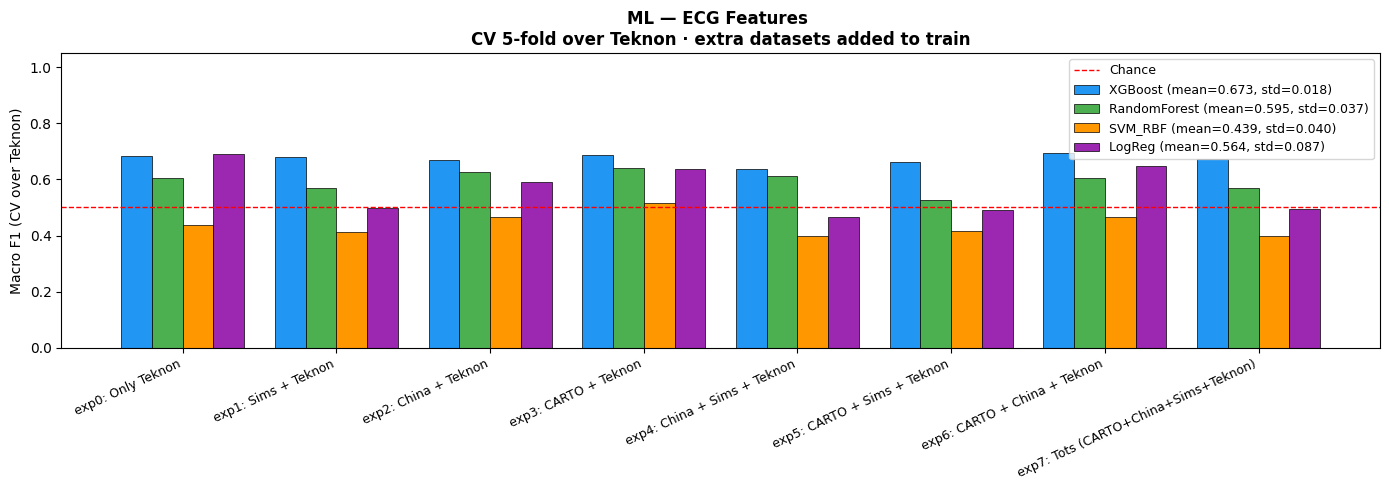

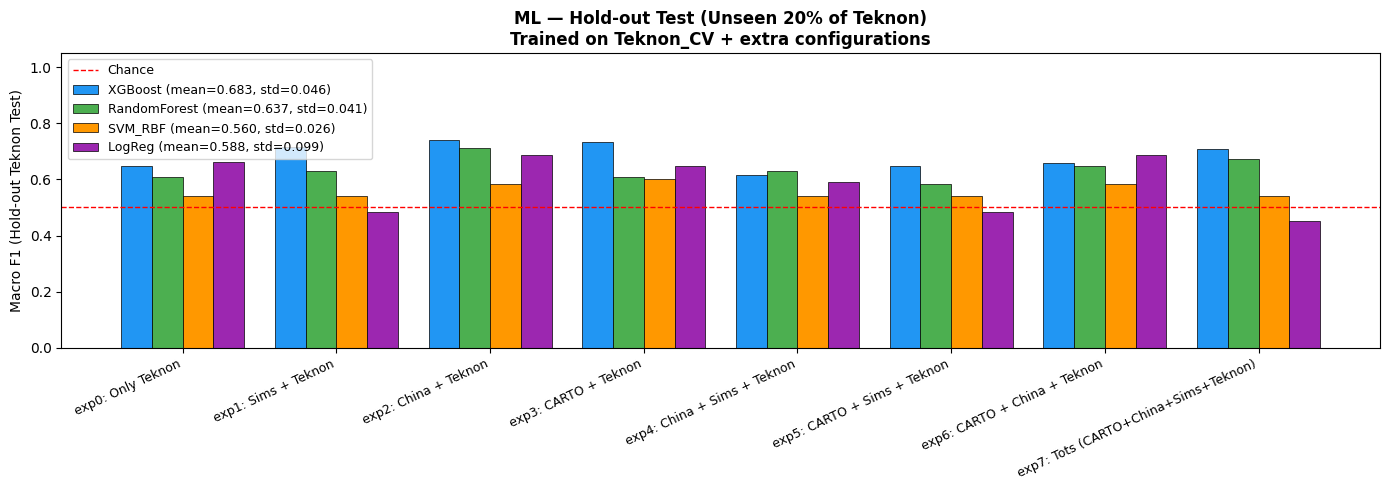

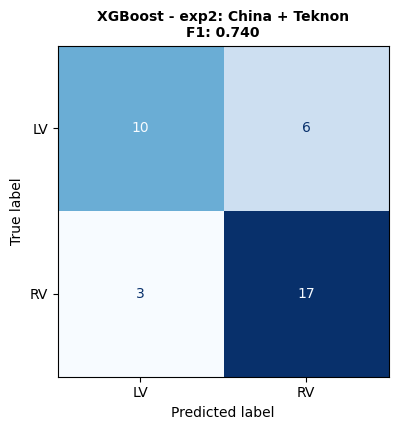

In [12]:
# Plotting and visualization

# Plot 1: Cross Validation Comparison
cv_title = 'ML — ECG Features \nCV 5-fold over Teknon · extra datasets added to train'
plot_results(df_resum, cv_title, 'Macro F1 (CV over Teknon)')

# Plot 2: Hold-out Metrics Comparison
ho_title = 'ML — Hold-out Test (Unseen 20% of Teknon)\nTrained on Teknon_CV + extra configurations'
plot_results(df_holdout, ho_title, 'Macro F1 (Hold-out Teknon Test)')

# Plot 3: Dynamic Best Model Confusion Matrix
if best_cm_data is not None:
    fig, ax = plt.subplots(figsize=(4.4, 4.4))
    disp = ConfusionMatrixDisplay(confusion_matrix=best_cm_data, display_labels=['LV', 'RV'])
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_title(f"{best_model_info['model']} - {best_model_info['experiment']}\nF1: {best_model_info['score']:.3f}", fontweight='bold', fontsize=10)
    plt.tight_layout()
    plt.show()

### 2. Best Model Refinement
Given that the best performing model is XGBoost on China+Teknon combination, a hyperparameter optimization is done to look for the best combination.


--- Tuning XGBoost on China + Teknon pool ---
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV Score (Macro F1): 0.7864
Best Hyperparameters: {'subsample': 0.9, 'reg_lambda': 10, 'n_estimators': 600, 'min_child_weight': 7, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.4, 'colsample_bytree': 0.6}

================ FINAL TEST RESULTS ================
Hold-out Test F1 Macro: 0.7926



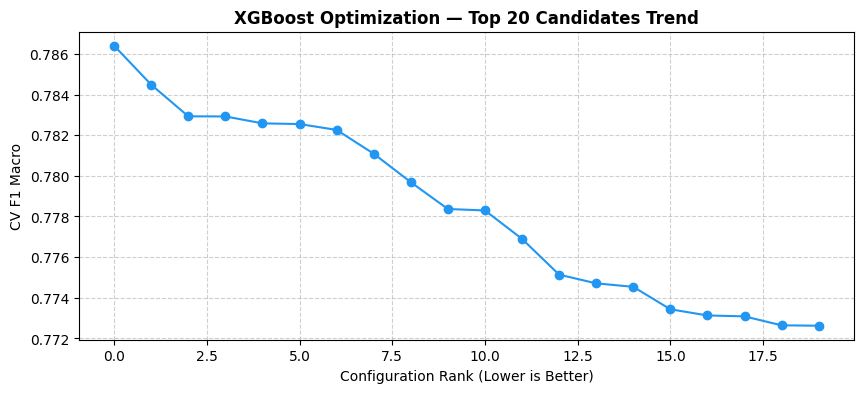

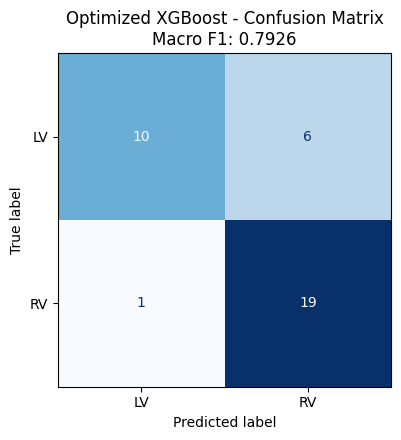

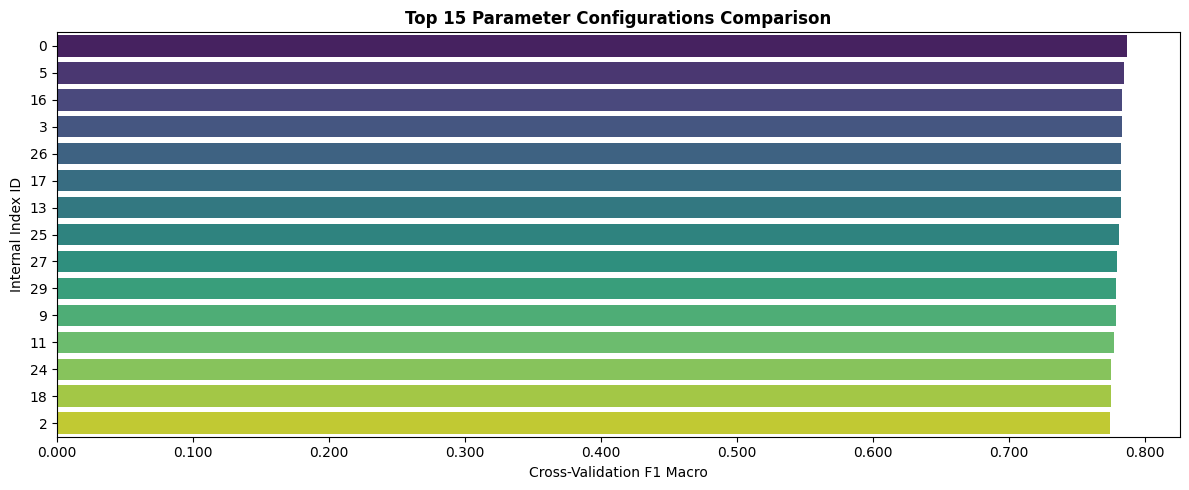

In [13]:
# Construct the dataset combination
X_train_augmented = np.concatenate([df_tek[FEATURE_COLS].values, df_china[FEATURE_COLS].values], axis=0)
y_train_augmented = np.concatenate([df_tek['target'].values, df_china['target'].values], axis=0).astype(np.int64)

# X_ho & y_ho already defined from previous hold-out evaluation

# Random search optimization for XGBoost
xgb_base = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric='logloss',
    tree_method='hist',
    random_state=RANDOM_STATE
)

param_dist = {
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": np.linspace(0.01, 0.15, 15),
    "n_estimators": [200, 400, 600, 800, 1000],
    "subsample": np.linspace(0.6, 1.0, 5),
    "colsample_bytree": np.linspace(0.6, 1.0, 5),
    "min_child_weight": [1, 3, 5, 7],
    "gamma": np.linspace(0, 0.5, 6),
    "reg_lambda": [1, 2, 5, 10]
}

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1_macro",
    cv=5,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("\n--- Tuning XGBoost on China + Teknon pool ---")
search.fit(X_train_augmented, y_train_augmented)

print(f"\nBest CV Score (Macro F1): {search.best_score_:.4f}")
print("Best Hyperparameters:", search.best_params_)

results_df = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")


# The best estimator comes already optimized and fitted on the entire training pool
best_xgb = search.best_estimator_

y_pred_ho = best_xgb.predict(X_ho)
test_f1 = f1_score(y_ho, y_pred_ho, average="macro", zero_division=0)

print("\n================ FINAL TEST RESULTS ================")
print(f"Hold-out Test F1 Macro: {test_f1:.4f}\n")


# Plot 1: Performance progression across evaluated iterations
plt.figure(figsize=(10, 4))
plt.plot(results_df["mean_test_score"].values[:20], marker="o", color="#2196F3")
plt.title("XGBoost Optimization — Top 20 Candidates Trend", fontweight='bold')
plt.xlabel("Configuration Rank (Lower is Better)")
plt.ylabel("CV F1 Macro")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Plot 2: Dynamic Best Model Confusion Matrix on unseen Test data
cm = confusion_matrix(y_ho, y_pred_ho)
fig, ax = plt.subplots(figsize=(4.5, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['LV', 'RV'])
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title(f"Optimized XGBoost - Confusion Matrix\nMacro F1: {test_f1:.4f}")
plt.tight_layout()
plt.show()

# Plot 3: Top 15 configurations benchmark comparison
top_configs = results_df.head(15).copy()
plt.figure(figsize=(12, 5))
sns.barplot(x="mean_test_score", y=top_configs.index.astype(str), data=top_configs, palette="viridis", hue=top_configs.index.astype(str), legend=False)
ax = plt.gca()
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
plt.title("Top 15 Parameter Configurations Comparison", fontweight='bold')
plt.xlabel("Cross-Validation F1 Macro")
plt.ylabel("Internal Index ID")
plt.tight_layout()
plt.show()

The shap analysis is done to the refined model to know what are the most relevant features to do the binary classification


Training final optimized XGBoost for SHAP analysis...
Computing SHAP values...

TOP FEATURES WITH STABILITY METRICS:


,feature,mean_shap,std_shap,mean_abs_shap,signal_to_noise
72,PVC_transition,0.2182,0.9757,0.8927,0.9150
33,aVF_RMS,0.0509,0.2345,0.2244,0.9569
63,V5_RMS,0.0488,0.2215,0.1921,0.8675
36,V1_R_amp,0.0195,0.1892,0.1752,0.9259
46,V2_Kurtosis,0.0373,0.1548,0.1491,0.9626
69,V6_RMS,0.0339,0.1359,0.1373,1.0107
2,I_RS_ratio,-0.0088,0.1373,0.1301,0.9478
44,V2_RS_ratio,0.0119,0.1194,0.1127,0.9432
42,V2_R_amp,0.0133,0.1058,0.0958,0.9054
14,III_RS_ratio,-0.0001,0.1037,0.0948,0.9146


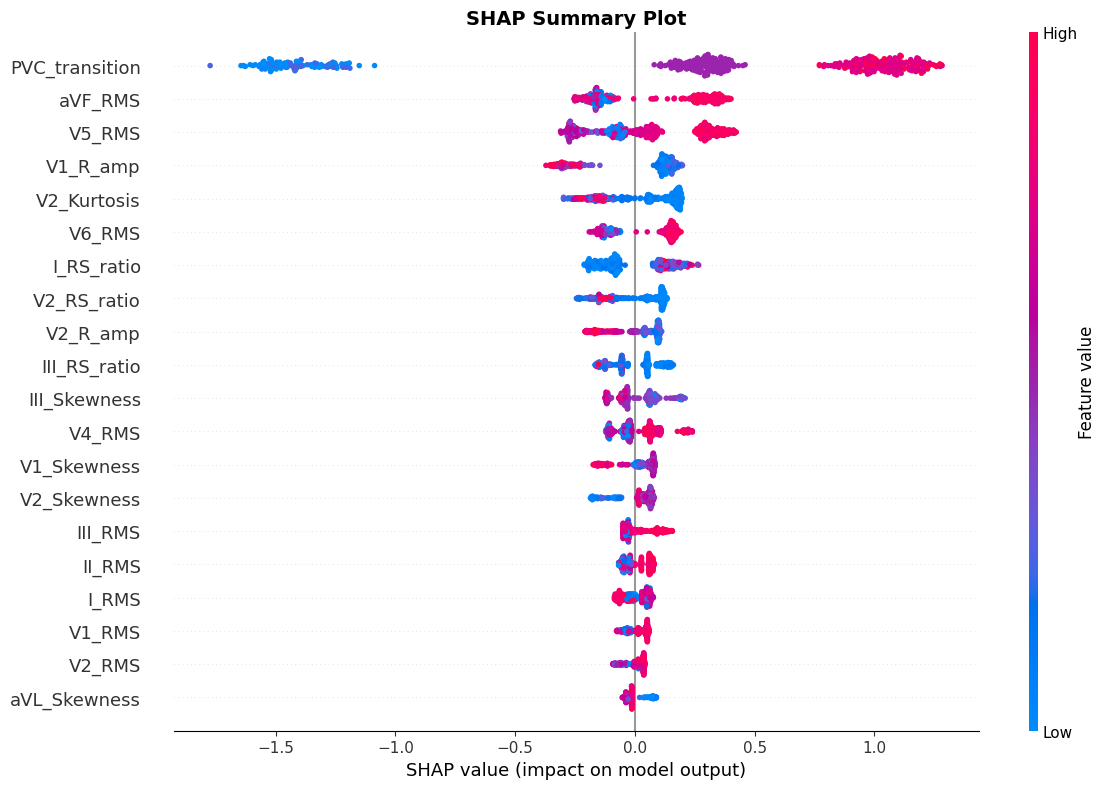

In [14]:
print("\nTraining final optimized XGBoost for SHAP analysis...")

# Initialize model using the best discovered parameters from your RandomizedSearchCV
shap_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric='logloss',
    tree_method='hist',
    random_state=RANDOM_STATE,
    **search.best_params_
)

# Train using the exact augmented imputed pool (Teknon CV + China) from your optimization step
shap_model.fit(X_train_augmented, y_train_augmented)

print("Computing SHAP values...")

# Create explainer and compute SHAP values for the training data pool
explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_train_augmented)

if isinstance(shap_values, list):
    # If returned as a list of classes, isolate class 1 (RV) impact
    shap_matrix = shap_values[1]
    is_list_output = True
else:
    shap_matrix = shap_values
    is_list_output = False

# Calculate stability metrics for each feature
mean_abs_shap = np.abs(shap_matrix).mean(axis=0)
std_shap = np.std(shap_matrix, axis=0)
mean_shap = np.mean(shap_matrix, axis=0)

df_shap_stats = pd.DataFrame({
    "feature": FEATURE_COLS,
    "mean_shap": mean_shap,
    "std_shap": std_shap,
    "mean_abs_shap": mean_abs_shap,
    "signal_to_noise": mean_abs_shap / (std_shap + 1e-8)
}).sort_values("mean_abs_shap", ascending=False)

print("\nTOP FEATURES WITH STABILITY METRICS:")
display(df_shap_stats.head(25).round(4))

# Compute and display differences in feature impact between classes if SHAP output is class-specific
if is_list_output:
    print("\nCLASS 0 (LV) vs CLASS 1 (RV) FEATURE IMPACT DIFFERENCES:")
    class0_impact = np.abs(shap_values[0]).mean(axis=0)
    class1_impact = np.abs(shap_values[1]).mean(axis=0)
    diff = class1_impact - class0_impact

    df_class_diff = pd.DataFrame({
        "feature": FEATURE_COLS,
        "class1_minus_class0_abs_impact": diff
    }).sort_values("class1_minus_class0_abs_impact", ascending=False)
    
    display(df_class_diff.head(25).round(4))



# Beeswarm Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_matrix,
    X_train_augmented,
    feature_names=FEATURE_COLS,
    max_display=20,
    show=False,
    plot_size=(12, 8)
)

plt.title("SHAP Summary Plot", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

### 3. China + Teknon + Clinical Data
In this trial we want to see if adding the available clinical data to the combination giving thee best performance will improve the prediction. However, since this data is only available for Teknon, and the algorithms used need uniform shapes, the corresponding values for China will be padded with zeroes. Given that constrain, we expect worse values.

Loading signals and identifiers...
Loading clinical data...
DEBUG: Coinciding patients: 177
Extracting features...

--- Carregant: data\QRS_Database2.mat ---
  Shape: (333, 12, 277)  |  LV=77  RV=256
Dataset Split Completed!
TRAIN SET (First 80%) shape: (141, 86) (Patients: 141)
TEST SET  (Last 20%)  shape: (36, 86) (Patients: 36)

Training models and evaluating with 5-Fold CV on the TRAIN SET...

Fold 1/5...
  • XGBoost                -> Fold Macro F1: 0.6184
  • Random Forest          -> Fold Macro F1: 0.4591
  • Support Vector Machine -> Fold Macro F1: 0.4658
  • Logistic Regression    -> Fold Macro F1: 0.5430

Fold 2/5...
  • XGBoost                -> Fold Macro F1: 0.4466
  • Random Forest          -> Fold Macro F1: 0.3665
  • Support Vector Machine -> Fold Macro F1: 0.3665
  • Logistic Regression    -> Fold Macro F1: 0.4759

Fold 3/5...
  • XGBoost                -> Fold Macro F1: 0.7418
  • Random Forest          -> Fold Macro F1: 0.6199
  • Support Vector Machine -> Fold Macro 

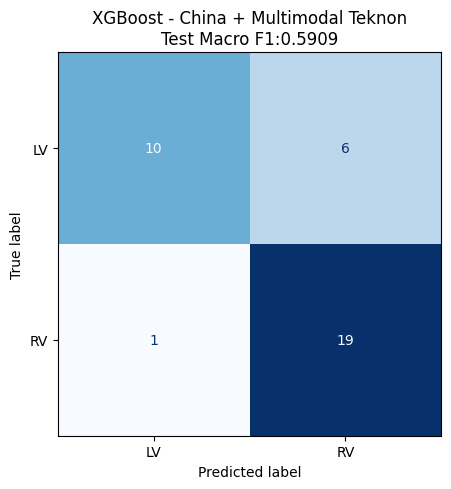

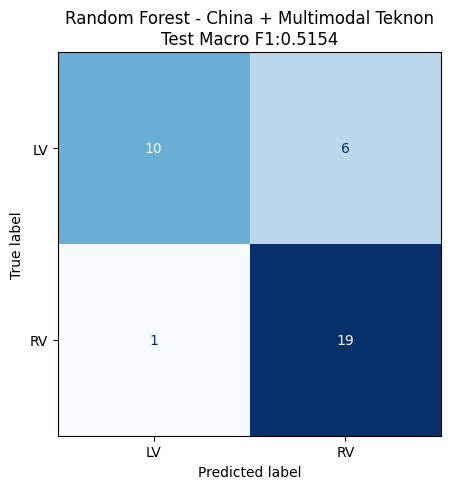

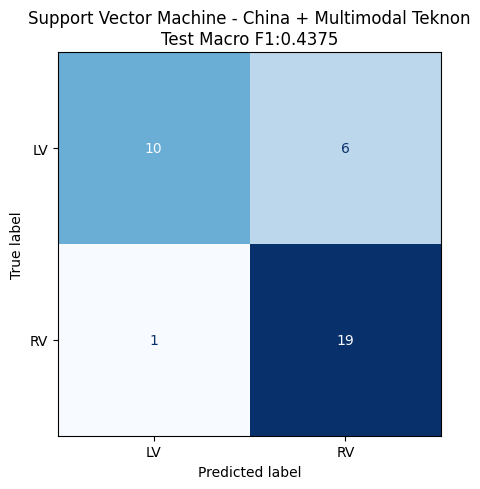

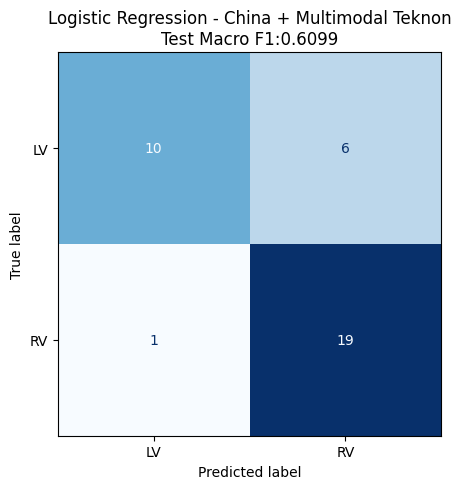

In [15]:
# Load the signals and identifiers
print("Loading signals and identifiers...")
with open(PATH_ALIGNED, 'rb') as f:
    aligned_ecgs = pickle.load(f)

with open(PATH_IDENTIFIERS, 'rb') as f:
    df_id = pickle.load(f)

X_teknon_all = np.array(aligned_ecgs, dtype=np.float32)
if X_teknon_all.shape[1] == SAMPLE_SIZE:
    X_teknon_all = np.transpose(X_teknon_all, (0, 2, 1))

print("Loading clinical data...")
df_clinics = pd.read_parquet(PATH_TABULAR_PARQUET)

if 'patient_id' in df_clinics.columns:
    df_clinics = df_clinics.set_index('patient_id')

# Sync patients between datasets
indices_comuns = df_id.index.intersection(df_clinics.index)
print(f"DEBUG: Coinciding patients: {len(indices_comuns)}")

if len(indices_comuns) == 0:
    raise ValueError("ERROR: No patients matching "
                     f"Example index df_id: {df_id.index[0]} | Example index df_clinics: {df_clinics.index[0]}")

posicions_ecg = [df_id.index.get_loc(idx) for idx in indices_comuns]
X_tek = X_teknon_all[posicions_ecg]
df_clinics = df_clinics.loc[indices_comuns].copy()


def extract_features(X_data, leads=LEADS):
    features_ecg_llista = []
    for i_pacient in range(len(X_data)):
        pacient_feats = {}
        for i_lead, lead_name in enumerate(leads):
            senyal = X_data[i_pacient, i_lead, :]

            r_amp = np.max(senyal)
            s_amp = np.min(senyal)
            rs_ratio = r_amp / (abs(s_amp) + 1e-6)
            rms = np.sqrt(np.mean(senyal**2))
            kurt = kurtosis(senyal)
            asimetria = skew(senyal)

            pacient_feats[f'{lead_name}_R_amp'] = r_amp
            pacient_feats[f'{lead_name}_S_amp'] = s_amp
            pacient_feats[f'{lead_name}_RS_ratio'] = rs_ratio
            pacient_feats[f'{lead_name}_RMS'] = rms
            pacient_feats[f'{lead_name}_Kurtosis'] = kurt
            pacient_feats[f'{lead_name}_Skewness'] = asimetria

        pacient_feats['PVC_transition'] = compute_transition(pacient_feats)
        features_ecg_llista.append(pacient_feats)
    return pd.DataFrame(features_ecg_llista)

print("Extracting features...")
df_features_ecg = extract_features(X_tek)
df_features_ecg.index = indices_comuns

if 'PVC_transition' in df_clinics.columns:
    df_clinics = df_clinics.drop(columns=['PVC_transition'])

# Fuse features + clinical data
df_tabular_final = pd.concat([df_clinics, df_features_ecg], axis=1)

TARGET_COL = 'Chamber_Type'

cols_to_drop = [
    'Final_Label', 'LVOTSUBVALVULAR', 'RVOTFREEWALL', 'SEPTUM',
    'COMMISSURE', 'LVOTSUMMIT', 'RVOTSEPTUM', '\\COMMISSURE',
    'site_of_origin', 'Site_Of_Origin', 'SOO', 'sublocation'
]
df_tabular_final = df_tabular_final.drop(columns=[c for c in cols_to_drop if c in df_tabular_final.columns])

# Normalize and map
df_tabular_final[TARGET_COL] = df_tabular_final[TARGET_COL].astype(str).str.strip().str.upper()
mapping = {'LV': 0, 'RV': 1, '0': 0, '1': 1}
df_tabular_final[TARGET_COL] = df_tabular_final[TARGET_COL].map(mapping)

# Drop rows with missing target labels and prepare X, y
df_tabular_final = df_tabular_final.dropna(subset=[TARGET_COL])

#Pulling China dataset using unified infrastructure functions
X_China, y_China, y_sub_China = load_dataset(PATH_CHINA, sample_size=SAMPLE_SIZE, data_key='QRS', sublocation=True, shuffle=False)

# Extract ECG features and PVC_transition for China
df_features_china = extract_features(X_China)
df_features_china[TARGET_COL] = y_China

# Align layouts filling missing clinical data with NaN values
df_china_final = pd.DataFrame(index=range(len(df_features_china)), columns=df_tabular_final.columns)
for col in df_features_china.columns:
    df_china_final[col] = df_features_china[col]

# Encode labels
y_all = df_tabular_final[TARGET_COL].values.astype(np.int64)
X_df_all = df_tabular_final.drop(columns=[TARGET_COL])
categorical_cols = X_df_all.select_dtypes(include=['object', 'category']).columns.tolist()
X_df_all = pd.get_dummies(X_df_all, columns=categorical_cols, drop_first=True)

X_df_china = df_china_final.drop(columns=[TARGET_COL])
X_df_china = pd.get_dummies(X_df_china, columns=categorical_cols, drop_first=True)
X_df_china = X_df_china.reindex(columns=X_df_all.columns, fill_value=np.nan)

X_all = X_df_all.values
X_china = X_df_china.values
y_china = df_china_final[TARGET_COL].values.astype(np.int64)

# Split dataset with hold-out 20%
split_idx = int(0.8 * len(df_tabular_final))

x_train = X_all[:split_idx]
y_train = y_all[:split_idx]

x_test = X_all[split_idx:]
y_test = y_all[split_idx:]

print(f"Dataset Split Completed!")
print(f"TRAIN SET (First 80%) shape: {x_train.shape} (Patients: {x_train.shape[0]})")
print(f"TEST SET  (Last 20%)  shape: {x_test.shape} (Patients: {x_test.shape[0]})\n")


# Cross-validation and evaluation of multiple models
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'XGBoost': xgb.XGBClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.05,
        random_state=42,
        eval_metric='logloss'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=150,
        max_depth=6,
        random_state=42
    ),
    'Support Vector Machine': SVC(
        kernel='rbf',
        C=1.0,
        probability=True,
        random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1500,
        random_state=42
    )
}

diccionari_scores = {nom_model: [] for nom_model in models.keys()}
diccionari_preds = {nom_model: [] for nom_model in models.keys()}
diccionari_reals = {nom_model: [] for nom_model in models.keys()}

print("Training models and evaluating with 5-Fold CV on the TRAIN SET...")

for fold, (train_idx, val_idx) in enumerate(skf.split(x_train, y_train), 1):
    print(f"\nFold {fold}/5...")

    X_train_fold, X_val_fold = x_train[train_idx], x_train[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

    # Combine extra China data only inside the training splits
    X_train_fold = np.concatenate([X_train_fold, X_china], axis=0)
    y_train_fold = np.concatenate([y_train_fold, y_china], axis=0)

    # Imputer and Scaler required for some ML architectures
    imputer = SimpleImputer(strategy='median')
    X_train_imputed = imputer.fit_transform(X_train_fold)
    X_val_imputed = imputer.transform(X_val_fold)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imputed)
    X_val_scaled = scaler.transform(X_val_imputed)

    # Select the imputed only for the needed models
    for nom_model, model in models.items():
        if nom_model in ['Support Vector Machine', 'Logistic Regression']:
            model.fit(X_train_scaled, y_train_fold)
            preds = model.predict(X_val_scaled)
        else:
            model.fit(X_train_imputed, y_train_fold)
            preds = model.predict(X_val_imputed)

        fold_f1 = f1_score(y_val_fold, preds, average='macro', zero_division=0)
        diccionari_scores[nom_model].append(fold_f1)

        diccionari_preds[nom_model].extend(preds)
        diccionari_reals[nom_model].extend(y_val_fold)

        print(f"  • {nom_model:<22} -> Fold Macro F1: {fold_f1:.4f}")

# Plot results per model
resum_experiments = []
for nom_model in models.keys():
    f1_mitjana = np.mean(diccionari_scores[nom_model])
    resum_experiments.append({
        'Model': nom_model,
        'CV Macro F1 average': f1_mitjana
    })

df_resultats_tabulars = pd.DataFrame(resum_experiments)
print("\nFinal Cross-Validation Results (on Train Set):")
print(df_resultats_tabulars.to_string(index=False))

# Evaluation on teknon
print("\nFinal hold-out test-set evaluation (Unseen 20% Teknon)")

x_train_full_with_extra = np.concatenate([x_train, X_china], axis=0)
y_train_full_with_extra = np.concatenate([y_train, y_china], axis=0)

full_imputer = SimpleImputer(strategy='median') #Canviar a zeros
X_train_full_imp = full_imputer.fit_transform(x_train_full_with_extra)
X_test_final_imp = full_imputer.transform(x_test)

full_scaler = StandardScaler()
X_train_full_scaled = full_scaler.fit_transform(X_train_full_imp)
X_test_final_scaled = full_scaler.transform(X_test_final_imp)

for nom_model, model in models.items():
    if nom_model in ['Support Vector Machine', 'Logistic Regression']:
        model.fit(X_train_full_scaled, y_train_full_with_extra)
        test_preds = model.predict(X_test_final_scaled)
    else:
        model.fit(X_train_full_imp, y_train_full_with_extra)
        test_preds = model.predict(X_test_final_imp)

    test_f1 = f1_score(y_test, test_preds, average='macro', zero_division=0)
    cm_test = confusion_matrix(y_test, test_preds)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['LV', 'RV'])

    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(cmap= 'Blues', ax=ax, colorbar=False)

    ax.set_title(f"{nom_model} - China + Multimodal Teknon\nTest Macro F1:{test_f1:.4f}")
    plt.tight_layout()
    plt.show()

### 4. Only Teknon with Clinical Data
We also wanted to try if adding clinical data available from the teknon dataset would improve the performance in a comparable way to adding more data (experiments above). To avoid imputing every value on the chinese dataset, this experiment was only done on the teknon dataset

Loading signals and identifiers...
Loading clinical data...
DEBUG: Coinciding patients: 177
Extracting features...
Dataset Split Completed!
TRAIN SET (First 80%) shape: (141, 86) (Patients: 141)
TEST SET  (Last 20%)  shape: (36, 86) (Patients: 36)

Training models and evaluating with 5-Fold CV on the TRAIN SET...

Fold 1/5...
  • XGBoost                -> Fold Macro F1: 0.5972
  • Random Forest          -> Fold Macro F1: 0.5695
  • Support Vector Machine -> Fold Macro F1: 0.4402
  • Logistic Regression    -> Fold Macro F1: 0.5496

Fold 2/5...
  • XGBoost                -> Fold Macro F1: 0.7812
  • Random Forest          -> Fold Macro F1: 0.7005
  • Support Vector Machine -> Fold Macro F1: 0.5942
  • Logistic Regression    -> Fold Macro F1: 0.6066

Fold 3/5...
  • XGBoost                -> Fold Macro F1: 0.7812
  • Random Forest          -> Fold Macro F1: 0.7005
  • Support Vector Machine -> Fold Macro F1: 0.4081
  • Logistic Regression    -> Fold Macro F1: 0.7005

Fold 4/5...
  • XGBoo

,Model,CV Macro F1 average
0,XGBoost,0.682638
1,Random Forest,0.640992
2,Support Vector Machine,0.490089
3,Logistic Regression,0.624690


Final hold-out test-set evaluation (Unseen 20% Teknon)

Model: XGBoost TestMACRO F1: 0.6990
 Confusion MatrixTest:
[[ 8  8]
 [ 2 18]]

Model: Random Forest TestMACRO F1: 0.6250
 Confusion MatrixTest:
[[ 6 10]
 [ 2 18]]

Model: Support Vector Machine TestMACRO F1: 0.5556
 Confusion MatrixTest:
[[ 6 10]
 [ 5 15]]

Model: Logistic Regression TestMACRO F1: 0.6494
 Confusion MatrixTest:
[[ 8  8]
 [ 4 16]]


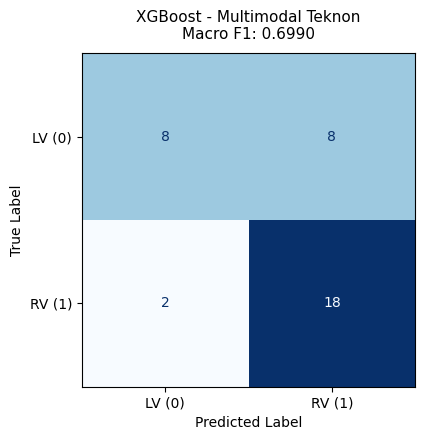

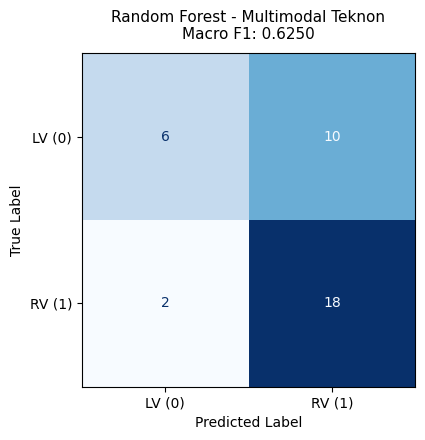

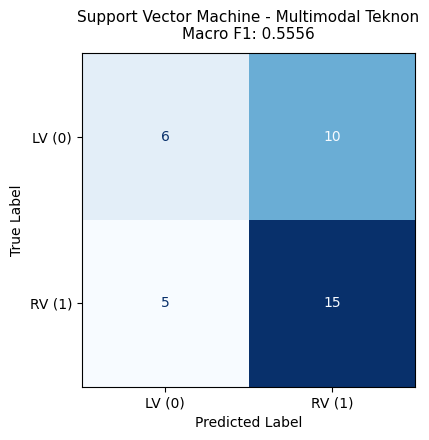

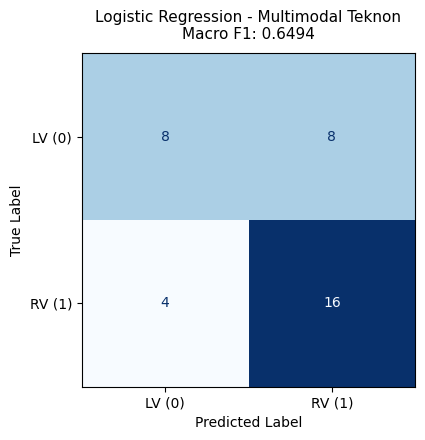

In [16]:
# REload the data to avoid leakage
print("Loading signals and identifiers...")
with open(PATH_ALIGNED, 'rb') as f:
    aligned_ecgs = pickle.load(f)

with open(PATH_IDENTIFIERS, 'rb') as f:
    df_id = pickle.load(f)

X_teknon_all = np.array(aligned_ecgs, dtype=np.float32)
if X_teknon_all.shape[1] == 277:
    X_teknon_all = np.transpose(X_teknon_all, (0, 2, 1))

print("Loading clinical data...")
df_clinics = pd.read_parquet(PATH_TABULAR_PARQUET)

if 'patient_id' in df_clinics.columns:
    df_clinics = df_clinics.set_index('patient_id')

# Sync patients between datasets
indices_comuns = df_id.index.intersection(df_clinics.index)
print(f"DEBUG: Coinciding patients: {len(indices_comuns)}")

if len(indices_comuns) == 0:
    raise ValueError("⚠️ ERROR CRÍTIC: No s'ha trobat cap coincidència de pacients. "
                     f"Exemple index df_id: {df_id.index[0]} | Exemple index df_clinics: {df_clinics.index[0]}")

posicions_ecg = [df_id.index.get_loc(idx) for idx in indices_comuns]
X_tek = X_teknon_all[posicions_ecg]
df_clinics = df_clinics.loc[indices_comuns].copy()


# Feature extraction from ECG signals
leads = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
features_ecg_llista = []

print("Extracting features...")
for i_pacient in range(len(X_tek)):
    pacient_feats = {}
    for i_lead, lead_name in enumerate(leads):
        senyal = X_tek[i_pacient, i_lead, :]

        # Key features
        r_amp = np.max(senyal) # Amplitude of R wave
        s_amp = np.min(senyal) # Amplitude of S wave
        rs_ratio = r_amp / (abs(s_amp) + 1e-6) # Ratio r-s to indicate side
        rms = np.sqrt(np.mean(senyal**2)) # Root Mean Square of the signal (power)
        kurt = kurtosis(senyal) # Kurtosis to measure "peakedness" of the signal distribution
        asimetria = skew(senyal) # Skewness to measure asymmetry of the signal

        pacient_feats[f'{lead_name}_R_amp'] = r_amp
        pacient_feats[f'{lead_name}_S_amp'] = s_amp
        pacient_feats[f'{lead_name}_RS_ratio'] = rs_ratio
        pacient_feats[f'{lead_name}_RMS'] = rms
        pacient_feats[f'{lead_name}_Kurtosis'] = kurt
        pacient_feats[f'{lead_name}_Skewness'] = asimetria

    features_ecg_llista.append(pacient_feats)

df_features_ecg = pd.DataFrame(features_ecg_llista, index=indices_comuns)


# Fuse features + clinical data
df_tabular_final = pd.concat([df_clinics, df_features_ecg], axis=1)

TARGET_COL = 'Chamber_Type'

cols_to_drop = [
    'Final_Label', 'LVOTSUBVALVULAR', 'RVOTFREEWALL', 'SEPTUM',
    'COMMISSURE', 'LVOTSUMMIT', 'RVOTSEPTUM', '\\COMMISSURE',
    'site_of_origin', 'Site_Of_Origin', 'SOO', 'sublocation'
]
df_tabular_final = df_tabular_final.drop(columns=[c for c in cols_to_drop if c in df_tabular_final.columns])

# Normalize and map
df_tabular_final[TARGET_COL] = df_tabular_final[TARGET_COL].astype(str).str.strip().str.upper()
mapping = {'LV': 0, 'RV': 1, '0': 0, '1': 1} #Include already binarized labels if present
df_tabular_final[TARGET_COL] = df_tabular_final[TARGET_COL].map(mapping)

# Drop rows with missing target labels and prepare X, y
df_tabular_final = df_tabular_final.dropna(subset=[TARGET_COL])
y_all = df_tabular_final[TARGET_COL].values.astype(np.int64)

# Encode other labels if necessary
X_df_all = df_tabular_final.drop(columns=[TARGET_COL])
categorical_cols = X_df_all.select_dtypes(include=['object', 'category']).columns.tolist()
X_df_all = pd.get_dummies(X_df_all, columns=categorical_cols, drop_first=True)
X_all = X_df_all.values


# Split dataset with hold-out 20%
split_idx = int(0.8 * len(df_tabular_final))

# Dividim la matriu X i el vector y seguint la teva lògica de talls indexats
x_train = X_all[:split_idx]
y_train = y_all[:split_idx]

x_test = X_all[split_idx:]
y_test = y_all[split_idx:]

print(f"Dataset Split Completed!")
print(f"TRAIN SET (First 80%) shape: {x_train.shape} (Patients: {x_train.shape[0]})")
print(f"TEST SET  (Last 20%)  shape: {x_test.shape} (Patients: {x_test.shape[0]})\n")


# Cross-validation and evaluation of multiple models
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Models to evaluate
models = {
    'XGBoost': xgb.XGBClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.05,
        random_state=42,
        eval_metric='logloss'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=150,
        max_depth=6,
        random_state=42
    ),
    'Support Vector Machine': SVC(
        kernel='rbf',
        C=1.0,
        probability=True,
        random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1500,
        random_state=42
    )
}

diccionari_scores = {nom_model: [] for nom_model in models.keys()}
diccionari_preds = {nom_model: [] for nom_model in models.keys()}
diccionari_reals = {nom_model: [] for nom_model in models.keys()}

print("Training models and evaluating with 5-Fold CV on the TRAIN SET...")

for fold, (train_idx, val_idx) in enumerate(skf.split(x_train, y_train), 1):
    print(f"\nFold {fold}/5...")

    X_train_fold, X_val_fold = x_train[train_idx], x_train[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

    # Impute nan values based only on the current fold train split
    imputer = SimpleImputer(strategy='median')
    X_train_imputed = imputer.fit_transform(X_train_fold)
    X_val_imputed = imputer.transform(X_val_fold)

    # Scale data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imputed)
    X_val_scaled = scaler.transform(X_val_imputed)

    # Train and evaluate each model on the validation fold
    for nom_model, model in models.items():
        if nom_model in ['Support Vector Machine', 'Logistic Regression']:
            model.fit(X_train_scaled, y_train_fold)
            preds = model.predict(X_val_scaled)
        else:
            model.fit(X_train_imputed, y_train_fold)
            preds = model.predict(X_val_imputed)

        # Calculate Macro F1 for the fold
        fold_f1 = f1_score(y_val_fold, preds, average='macro', zero_division=0)
        diccionari_scores[nom_model].append(fold_f1)

        # Save validation fold metrics for aggregated confusion matrix
        diccionari_preds[nom_model].extend(preds)
        diccionari_reals[nom_model].extend(y_val_fold)

        print(f"  • {nom_model:<22} -> Fold Macro F1: {fold_f1:.4f}")


# Reporting CV results
resum_experiments = []
for nom_model in models.keys():
    f1_mitjana = np.mean(diccionari_scores[nom_model])
    resum_experiments.append({
        'Model': nom_model,
        'CV Macro F1 average': f1_mitjana
    })

df_resultats_tabulars = pd.DataFrame(resum_experiments)
print("\nFinal Cross-Validation Results (on Train Set):")
display(df_resultats_tabulars)


print("Final hold-out test-set evaluation (Unseen 20% Teknon)")

# Imputem i escalem el bloc de test usant l'imputer/scaler ajustat amb tot el 80% de Train
full_imputer = SimpleImputer(strategy='median')
X_train_full_imp = full_imputer.fit_transform(x_train)
X_test_final_imp = full_imputer.transform(x_test)

full_scaler = StandardScaler()
X_train_full_scaled = full_scaler.fit_transform(X_train_full_imp)
X_test_final_scaled = full_scaler.transform(X_test_final_imp)


for nom_model, model in models.items():
    # Re-entrenem el model amb el 100% de les dades del conjunt de Train (80%)
    if nom_model in ['Support Vector Machine', 'Logistic Regression']:
        model.fit(X_train_full_scaled, y_train)
        test_preds = model.predict(X_test_final_scaled)
    else:
        model.fit(X_train_full_imp, y_train)
        test_preds = model.predict(X_test_final_imp)

    test_f1 = f1_score(y_test, test_preds, average='macro', zero_division=0)
    cm_test = confusion_matrix(y_test, test_preds)
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['LV (0)', 'RV (1)'])
    disp.plot(cmap='Blues', ax=ax, colorbar=False, values_format='d')

    ax.set_title(f"{nom_model} - Multimodal Teknon\nMacro F1: {test_f1:.4f}", fontsize=11, pad=10)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)
    plt.tight_layout()

    print(f"\nModel: {nom_model} TestMACRO F1: {test_f1:.4f}")
    print(" Confusion MatrixTest:")
    print(cm_test)

Since XGBoost is the best performing model, the hyperparameter study is done to see if the performance can be increased.


=== XGBOOST HYPERPARAMETER OPTIMIZATION ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits

BEST PARAMS:
{'subsample': 0.9, 'reg_lambda': 10, 'n_estimators': 600, 'min_child_weight': 7, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.4, 'colsample_bytree': 0.6}

BEST CV SCORE:
0.7233979205954421


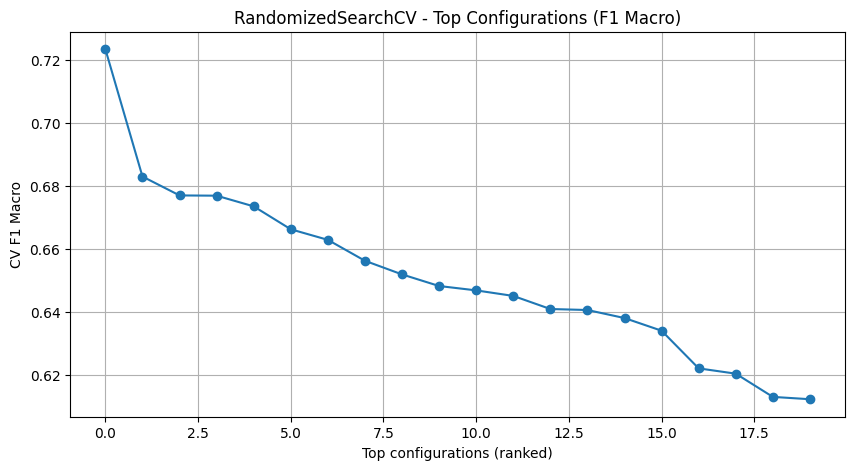


================ FINAL TEST RESULTS ================

TEST F1 MACRO: 0.7855


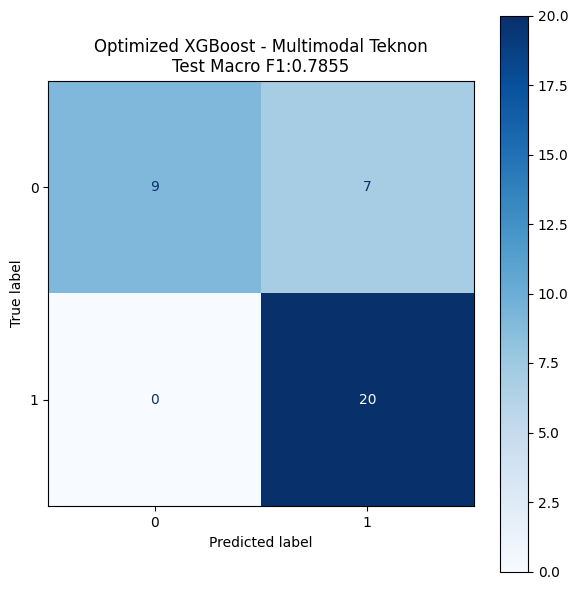

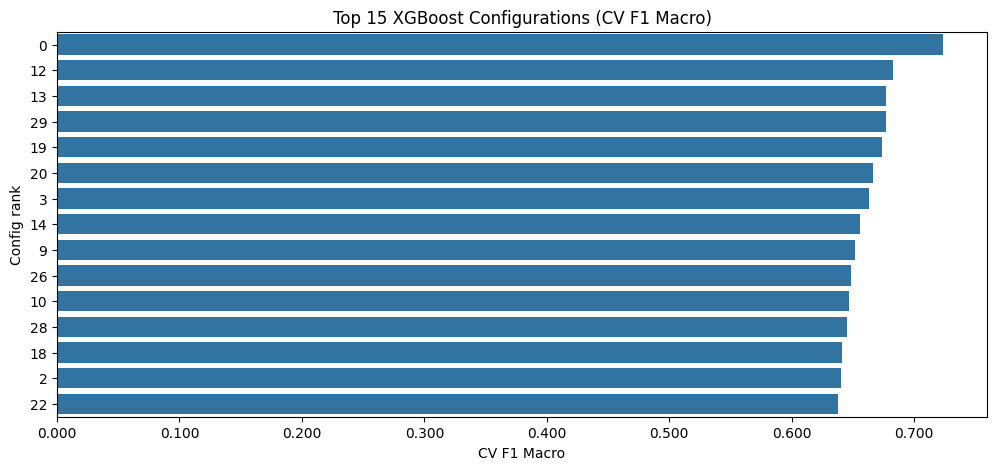

In [17]:
CLASS_NAMES = np.unique(y_all)

print("\n=== XGBOOST HYPERPARAMETER OPTIMIZATION ===")

# Impute to ensure no nan values
imputer = SimpleImputer(strategy='median')

X_train_imp = imputer.fit_transform(x_train)
X_test_imp = imputer.transform(x_test)

# base model
xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=42
)

# DEfined parameter distribution
param_dist = {
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": np.linspace(0.01, 0.15, 15),
    "n_estimators": [200, 400, 600, 800, 1000],
    "subsample": np.linspace(0.6, 1.0, 5),
    "colsample_bytree": np.linspace(0.6, 1.0, 5),
    "min_child_weight": [1, 3, 5, 7],
    "gamma": np.linspace(0, 0.5, 6),
    "reg_lambda": [1, 2, 5, 10]
}

# Random search
search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1_macro",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_imp, y_train)

print("\nBEST PARAMS:")
print(search.best_params_)

print("\nBEST CV SCORE:")
print(search.best_score_)

# Results
results_df = pd.DataFrame(search.cv_results_)
results_df = results_df.sort_values("rank_test_score")

# Plot CV performance per configuration
plt.figure(figsize=(10,5))
plt.plot(
    results_df["mean_test_score"].values[:20],
    marker="o"
)
plt.title("RandomizedSearchCV - Top Configurations (F1 Macro)")
plt.xlabel("Top configurations (ranked)")
plt.ylabel("CV F1 Macro")
plt.grid()
plt.show()

# Train the best configuration
best_model = search.best_estimator_
best_model.fit(X_train_imp, y_train) # possiblement innecessari

# Final test
y_pred = best_model.predict(X_test_imp)
test_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print("\n================ FINAL TEST RESULTS ================\n")
print(f"TEST F1 MACRO: {test_f1:.4f}")

# Display the confusion matrix for the best configuration
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6,6))
ConfusionMatrixDisplay(
    cm,
    display_labels=CLASS_NAMES
).plot(ax=ax, cmap="Blues", values_format="d")

plt.title(f"Optimized XGBoost - Multimodal Teknon\nTest Macro F1:{test_f1:.4f}")
plt.tight_layout()
plt.show()

#Top 10 configurations plot
top = results_df.head(15).copy()
plt.figure(figsize=(12,5))
sns.barplot(
    x="mean_test_score",
    y=top.index.astype(str),
    data=top
)

ax = plt.gca()
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

plt.title("Top 15 XGBoost Configurations (CV F1 Macro)")
plt.xlabel("CV F1 Macro")
plt.ylabel("Config rank")
plt.show()